In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ACTIVATIONS_ROOT = './activations/'
DATASET_ROOT = './datasets'

label_fontsize = 18

In [2]:
import torch

use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available() and False

if use_cuda:
    device = torch.device("cuda")
elif use_mps:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [3]:
from src.rmt_utils import solve_stieltjes
from src.power_law_utils import power_law_diag_matrix, sample_power_law_matrix

In [4]:
def compute_self_overlap(λ, λ_tilde, q, eta=1e-15, max_iter=10000, tol=1e-6):

    λ = torch.from_numpy(λ).to(torch.float64)
    λ_tilde = torch.from_numpy(λ_tilde).to(torch.float64)

    P = len(λ_tilde)
    λ = λ.to(torch.float64)
    λ_tilde = λ_tilde.to(torch.float64)

    stj_z = solve_stieltjes(λ, λ_tilde, q, eta=eta, max_iter=max_iter, tol=tol)
    hil_E = torch.real(stj_z)
    rho_E = torch.imag(stj_z) / torch.pi

    Mu = λ_tilde[None, :]
    Lambda = λ[:, None]
    hil_E = hil_E[:, None]
    rho_E = rho_E[:, None]

    numerator = q * Mu * Lambda
    denominator_real = Mu * (1 - q) - Lambda + q * Mu * Lambda * hil_E
    denominator_imag = q * Mu * Lambda * torch.pi * rho_E
    denominator = denominator_real**2 + denominator_imag**2
    Q_th = numerator / denominator
    Q_th /= P  # We divide by P to obtain the matrix Q_{ij}

    factor1 = Mu*rho_E
    factor2 = Lambda*hil_E-1

    return Q_th, denominator_real**2, denominator_imag**2, numerator, rho_E, hil_E, factor1, factor2

In [5]:
def overlap_pop_sample(pop_matrix, sample_size, num_trials):

    print(f"neuron_size={sample_size}")
    overlap_matrices = []
    eigevalue_2_list = []
    for _ in range(num_trials):

        # Generate sample matrix by taking the first sample_size columns
        R = torch.randn(pop_matrix.shape[0], sample_size, device=pop_matrix.device, dtype=pop_matrix.dtype)
        sample_matrix = torch.sqrt(pop_matrix) @ R
        sample_gram = sample_matrix @ sample_matrix.T / sample_size

        # Compute eigenvalues and eigenvectors
        # eig_values1, eig_vectors1 = torch.linalg.eigh(pop_matrix)
        eig_values2, eig_vectors2 = torch.linalg.eigh(sample_gram)
        eig_values2 = eig_values2.flip(dims=(0,))
        eig_vectors2 = eig_vectors2.flip(dims=(1,))

        # align eig_vectors2 so that eig_vector[i,i] > 0
        # for i in range(eig_vectors2.shape[1]):
        #     if eig_vectors2[i,i] < 0:
        #         eig_vectors2[:,i] = -eig_vectors2[:,i]
        # Get overlap matrix
        # overlap_matrix = eig_vectors1.t() @ eig_vectors2
        overlap_matrix = eig_vectors2
        overlap_matrix = (overlap_matrix**2)
        overlap_matrices.append(overlap_matrix)
        eigevalue_2_list.append(eig_values2)

    # Stack overlap matrices along a new dimension
    overlap_matrices_stack = torch.stack(overlap_matrices)

    # Compute mean and standard deviation across trials
    avg_overlap_pop_sample = overlap_matrices_stack.mean(dim=0)
    std_overlap_pop_sample = overlap_matrices_stack.std(dim=0)
    # get mean of the second eigenvalue
    avg_eig_value2 = torch.stack(eigevalue_2_list).mean(dim=0)

    return avg_overlap_pop_sample.cpu(), overlap_matrices_stack.cpu(), avg_eig_value2.cpu()

In [6]:
P_list = [40, 201, 1000]
N_list = np.logspace(1, 3, 4, dtype=int)
a_list = [0.2]
num_trials = 200

threshold_empirical_dict = {}
overlap_diag_theory_dict = {}
mean_dict = {}
ranks = {}
for a in a_list:
    for P_index, P in enumerate(P_list):
        for N in N_list:

            label = f"P={P}, N={N}, a={a}"

            exponent = 1 + a
            pop_matrix = power_law_diag_matrix(P, exponent, device=device)
            mean, whole, e_value2 = overlap_pop_sample(pop_matrix, N, num_trials=num_trials)
            e_value1 = torch.diag(pop_matrix)

            e_value1 = e_value1.cpu().numpy()
            e_value2 = e_value2.cpu().numpy()

            q = P / N
            eta = 1 / np.sqrt(P)**2

            (overlap_theory, real_part_theory, imag_part_theory, numerator_theory,
             _, _, _, _) = compute_self_overlap(e_value2, e_value1, q, eta=eta,
                                                max_iter=10000, tol=1e-6)

            overlap_diag_theory = np.diag(overlap_theory)
            threshold_idx_empirical = np.argmax(overlap_diag_theory < 0.6)
            rank = int(0.8*min(P, N))

            print(f"P={P}, N={N}, a={a}, threshold_idx_empirical={threshold_idx_empirical}")
            threshold_empirical_dict[label] = {"threshold_idx": threshold_idx_empirical}
            overlap_diag_theory_dict[label] = overlap_diag_theory
            ranks[label] = rank
            mean_dict[label] = mean

neuron_size=10
P=40, N=10, a=0.2, threshold_idx_empirical=1
neuron_size=46
P=40, N=46, a=0.2, threshold_idx_empirical=2
neuron_size=215
P=40, N=215, a=0.2, threshold_idx_empirical=6
neuron_size=1000
P=40, N=1000, a=0.2, threshold_idx_empirical=15
neuron_size=10
P=201, N=10, a=0.2, threshold_idx_empirical=1
neuron_size=46
P=201, N=46, a=0.2, threshold_idx_empirical=2
neuron_size=215
P=201, N=215, a=0.2, threshold_idx_empirical=6
neuron_size=1000
P=201, N=1000, a=0.2, threshold_idx_empirical=14
neuron_size=10
P=1000, N=10, a=0.2, threshold_idx_empirical=1
neuron_size=46
P=1000, N=46, a=0.2, threshold_idx_empirical=2
neuron_size=215
P=1000, N=215, a=0.2, threshold_idx_empirical=6
neuron_size=1000
P=1000, N=1000, a=0.2, threshold_idx_empirical=0


P=201, N=10, a=0.2
P=201, N=46, a=0.2
P=201, N=215, a=0.2
P=201, N=1000, a=0.2


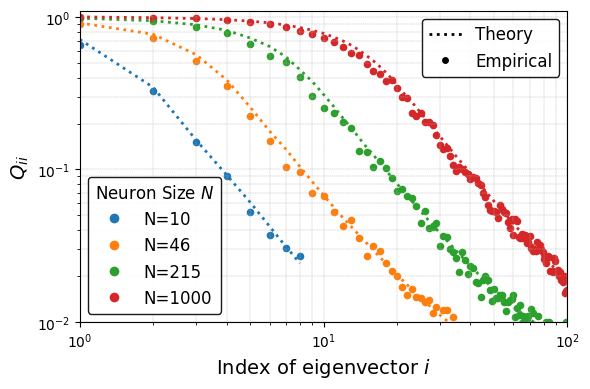

In [7]:
plt.style.use('default')
plt.figure(figsize=(6, 4))

for a in a_list:
    for P_index, P in enumerate([201]):
        for N in N_list:

            label = f"P={P}, N={N}, a={a}"
            print(label)

            overlap_diag_theory = overlap_diag_theory_dict[label]
            threshold_idx_empirical = threshold_empirical_dict[label]["threshold_idx"]
            rank = ranks[label]
            mean = mean_dict[label]

            color = plt.cm.tab10(np.where(N_list == N)[0][0])  # Consistent color mapping
            plt.plot(np.arange(1, rank+1), overlap_diag_theory[:rank], linestyle=':', color=color, linewidth=2)
            plt.scatter(np.arange(1, rank+1), mean.diagonal()[: rank], color=color, s=20)
            plt.xscale('log')
            plt.yscale('log')

        # Create legends
        linestyle_legend = [
            Line2D([0], [0], color='black', linestyle=':', label=f"Theory", lw=2),
            Line2D([0], [0], marker='o', color='w', label='Empirical', markerfacecolor='black', markersize=6)
        ]

        color_legend = []
        for N in N_list:
            color = plt.cm.tab10(np.where(N_list == N)[0][0])
            color_legend.append(Line2D([0], [0], marker='o', color='w',
                                label=f"N={N}", markerfacecolor=color, markersize=8))

        first_legend = plt.legend(handles=linestyle_legend, loc='upper right', fontsize=12,
                                  frameon=True, framealpha=0.9, edgecolor='black', fancybox=True)
        plt.gca().add_artist(first_legend)

        plt.legend(handles=color_legend, loc='lower left', fontsize=12, frameon=True, framealpha=0.9,
                   edgecolor='black', fancybox=True, title=r'Neuron Size $N$', title_fontsize=12)

plt.xlabel(r"Index of eigenvector $i$", fontsize=14)
plt.ylabel(r"$Q_{ii}$", fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.3)
plt.ylim(1e-2, 1.1)
plt.xlim(1, 100)
plt.tight_layout()
# plt.savefig('./figures/Q_ii_theory_empirical.pdf')

P=40, N=10, a=0.2
P=40, N=46, a=0.2
P=40, N=215, a=0.2
P=40, N=1000, a=0.2
P=201, N=10, a=0.2
P=201, N=46, a=0.2
P=201, N=215, a=0.2
P=201, N=1000, a=0.2
P=1000, N=10, a=0.2
P=1000, N=46, a=0.2
P=1000, N=215, a=0.2
P=1000, N=1000, a=0.2


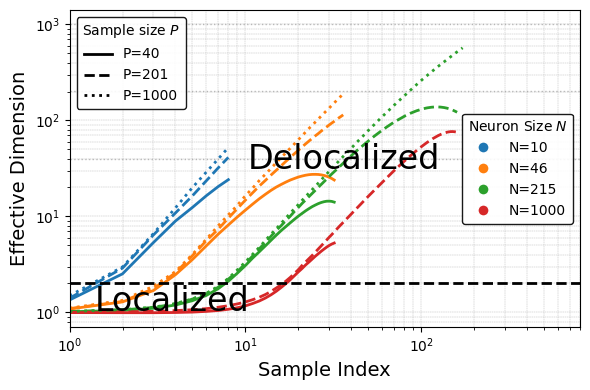

In [8]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(6, 4))

linestyles = ['-', '--', ':']

# Calculate and plot effective dimension for each configuration
for P_index, P in enumerate(P_list):
    for N in N_list:

        label = f"P={P}, N={N}, a={a}"
        print(label)

        overlap_diag_theory = overlap_diag_theory_dict[label]
        rank = ranks[label]
        dimension_list = 1 / np.sum(overlap_diag_theory.reshape(-1, 1), axis=1)  # effective dimension

        color = plt.cm.tab10(np.where(N_list == N)[0][0])  # Consistent color for each N
        ax.plot(np.arange(1, rank+1), dimension_list[:rank], color=color,
                linestyle=linestyles[P_index], linewidth=2)

    ax.axhline(y=P, color='gray', linestyle=':', alpha=0.5, linewidth=1)

# plot horizontal line at y=2
ax.axhline(y=2, color='black', linestyle='--', linewidth=2)

# Add text annotations
ax.text(0.05, 0.05, 'Localized', transform=ax.transAxes, fontsize=24)
ax.text(0.35, 0.5, 'Delocalized', transform=ax.transAxes, fontsize=24)

# Create legends
linestyle_legend = [Line2D([0], [0], color='black', linestyle=style, label=f"P={P}", lw=2)
                    for style, P in zip(linestyles, P_list)]

color_legend = [Line2D([0], [0], marker='o', color='w', label=f"N={N}", markerfacecolor=color, markersize=8)
                for N, color in zip(N_list, [plt.cm.tab10(i) for i in range(len(N_list))])]

# Add legends
first_legend = ax.legend(handles=linestyle_legend, loc='upper left',
                         fontsize=10, frameon=True, framealpha=0.9,
                         edgecolor='black', fancybox=True,
                         title=r"Sample size $P$")
ax.add_artist(first_legend)
ax.legend(handles=color_legend, loc='center right',
          fontsize=10, frameon=True, framealpha=0.9,
          edgecolor='black', fancybox=True,
          title=r'Neuron Size $N$')

# Customize plot
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Sample Index', fontsize=14)
ax.set_ylabel('Effective Dimension', fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.3)

# Set x limits to the maximum rank we're plotting
max_rank = int(0.8 * min(max(P_list), max(N_list)))
ax.set_xlim(1, max_rank)


plt.tight_layout()
# plt.savefig('effective_dimension_varying_P_varying_N.pdf', bbox_inches='tight')
plt.show()

P=40, N=10, a=0.2
P=40, N=46, a=0.2
P=40, N=215, a=0.2
P=40, N=1000, a=0.2
P=201, N=10, a=0.2
P=201, N=46, a=0.2
P=201, N=215, a=0.2
P=201, N=1000, a=0.2
P=1000, N=10, a=0.2
P=1000, N=46, a=0.2
P=1000, N=215, a=0.2
P=1000, N=1000, a=0.2


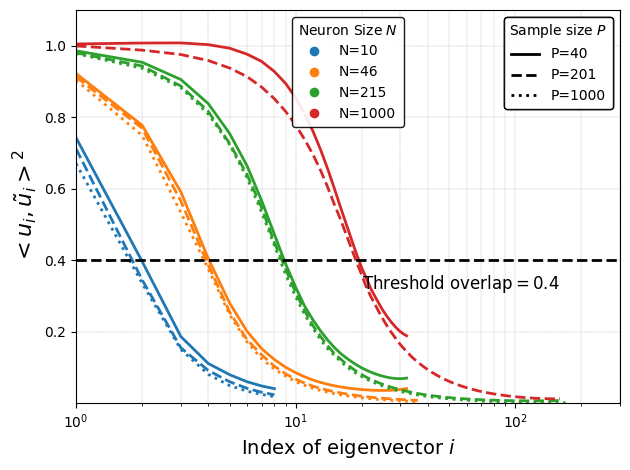

In [9]:
P_list = [40, 201, 1000]
N_list = np.logspace(1, 3, 4, dtype=int)
a_list = [0.2]
num_trials = 200

for a in a_list:
    for P_index, P in enumerate(P_list):
        for N in N_list:

            label = f"P={P}, N={N}, a={a}"
            print(label)

            overlap_diag_theory = overlap_diag_theory_dict[label]
            threshold_idx_empirical = threshold_empirical_dict[label]["threshold_idx"]
            rank = ranks[label]
            mean = mean_dict[label]

            color = plt.cm.tab10(np.where(N_list == N)[0][0])

            skip = 1
            if P_index == 0:
                plt.plot(np.arange(1, rank + 1), overlap_diag_theory[:rank], color=color, linewidth=2)

            elif P_index == 1:
                plt.plot(np.arange(1, rank + 1), overlap_diag_theory[:rank], linestyle='--', color=color, linewidth=2)

            elif P_index == 2:
                plt.plot(np.arange(1, rank + 1), overlap_diag_theory[:rank], linestyle=':', color=color, linewidth=2)

            plt.xscale('log')

        plt.xlabel(r"Index of eigenvector $i$", fontsize=14)
        plt.ylabel(r"$<u_i, \tilde{u}_i>^2$", fontsize=16)
        plt.grid(True, which='both', linestyle='--', linewidth=0.3)
        plt.ylim(1 / P, 1.1)
        plt.xlim(1, 300)
        linestyle_legend = [Line2D([0], [0], color='black', linestyle='solid', label=f"P={P_list[0]}", lw=2),
                            Line2D([0], [0], color='black', linestyle='--', label=f"P={P_list[1]}", lw=2),
                            Line2D([0], [0], color='black', linestyle='dotted', label=f"P={P_list[2]}", lw=2)]

        # Color legend for different N values(color in circle dot)
        color_legend = []
        for N in N_list:
            color = plt.cm.tab10(np.where(N_list == N)[0][0])
            color_legend.append(Line2D([0], [0], marker='o', color='w',
                                label=f"N={N}", markerfacecolor=color, markersize=8))

        # Plot the two separate legends
        first_legend = plt.legend(handles=linestyle_legend, loc='upper right', fontsize=10,
                                  frameon=True, framealpha=0.9, edgecolor='black',
                                  fancybox=True, title=r"Sample size $P$")
        plt.gca().add_artist(first_legend)  # Add the first legend to the plot

        # Second legend for the colors
        plt.legend(handles=color_legend, loc='upper center', fontsize=10, frameon=True,
                   framealpha=0.9, edgecolor='black', fancybox=True, title=r'Neuron Size $N$')


plt.text(20, 0.32, r'$\text{Threshold overlap}=0.4$', fontsize=12)
plt.axhline(y=0.4, color='black', linestyle='--', linewidth=2)

plt.tight_layout()
# plt.savefig('./figures/overlap_varying_N_varying_P.pdf')

threshold=6.28784071850491


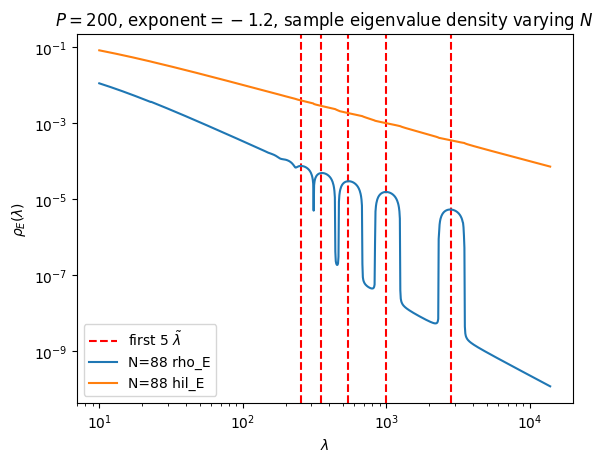

In [10]:
P_values = [200]
threshold = 3
N_values = [int((3.14*threshold)**2)]
exponent_values = [-1.5]
rho_E_dict = {}
for P in P_values:
    for N in N_values:
        for exponent in exponent_values:

            q = P / N
            eta = 1 / np.sqrt(P)

            λ_tilde = (np.arange(1, P+1) / P)**exponent
            λ = np.logspace(np.log10(10*min(λ_tilde)), 1.2*np.log10(max(λ_tilde)), 1000)

            (mso, denominator_real, denominator_imag, numerator,
             rho_E_list, hil_E_list, factor1, factor2) = compute_self_overlap(λ, λ_tilde, q, eta=eta,
                                                                              max_iter=10000, tol=1e-6)

            rho_E_list = np.array(rho_E_list)
            hil_E_list = np.array(hil_E_list)
            denominator_real = np.array(denominator_real)
            denominator_imag = np.array(denominator_imag)
            factor1 = np.array(factor1)
            factor2 = np.array(factor2)
            # save mu,lamda,rho_E,hil_E in dictionary
            rho_E_dict[(P, N, exponent)] = {"mu": λ_tilde, "lambda": λ, "rho_E": rho_E_list, "hil_E": hil_E_list,
                                            "denominator_real": denominator_real, "denominator_imag": denominator_imag,
                                            "factor1": factor1, "factor2": factor2}

for P in P_values:
    for N in N_values:
        for exponent in exponent_values:

            data = rho_E_dict[(P, N, exponent)]
            λ = data["lambda"]
            λ_tilde = data["mu"]
            rho_E = data["rho_E"]
            hil_E = data["hil_E"]
            denominator_real = data["denominator_real"]
            denominator_imag = data["denominator_imag"]
            factor1 = data["factor1"]
            factor2 = data["factor2"]

            print(f"threshold={(1+np.sqrt(P/N))**2}")
            if N == N_values[0]:
                for i in range(5):
                    plt.axvline(x=λ_tilde[i], color='r', linestyle='--',
                                label=r"first 5 $\tilde{\lambda}$" if i == 0 else "")

            plt.loglog(λ, np.abs(rho_E), label=f"N={N:.0f} rho_E")
            plt.loglog(λ, np.abs(hil_E), label=f"N={N:.0f} hil_E")

plt.yscale('log')
plt.xscale('log')
# set x and y scale same, so box
# plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\rho_E(\lambda)$')
plt.legend()
plt.title(r"$P=200$, exponent$=-1.2$, sample eigenvalue density varying $N$")
plt.show()

P=40, N=10, a=0.2
neuron_size=10
P=40, N=10, a=0.2, threshold_idx_empirical=1
P=40, N=31, a=0.2
neuron_size=31
P=40, N=31, a=0.2, threshold_idx_empirical=3
P=40, N=100, a=0.2
neuron_size=100
P=40, N=100, a=0.2, threshold_idx_empirical=5
P=40, N=316, a=0.2
neuron_size=316
P=40, N=316, a=0.2, threshold_idx_empirical=10
P=201, N=10, a=0.2
neuron_size=10
P=201, N=10, a=0.2, threshold_idx_empirical=1
P=201, N=31, a=0.2
neuron_size=31
P=201, N=31, a=0.2, threshold_idx_empirical=3
P=201, N=100, a=0.2
neuron_size=100
P=201, N=100, a=0.2, threshold_idx_empirical=5
P=201, N=316, a=0.2
neuron_size=316
P=201, N=316, a=0.2, threshold_idx_empirical=10
P=1000, N=10, a=0.2
neuron_size=10
P=1000, N=10, a=0.2, threshold_idx_empirical=1
P=1000, N=31, a=0.2
neuron_size=31
P=1000, N=31, a=0.2, threshold_idx_empirical=3
P=1000, N=100, a=0.2
neuron_size=100
P=1000, N=100, a=0.2, threshold_idx_empirical=5
P=1000, N=316, a=0.2
neuron_size=316
P=1000, N=316, a=0.2, threshold_idx_empirical=10


Text(20, 0.32, '$\\text{Threshold overlap}=0.4$')

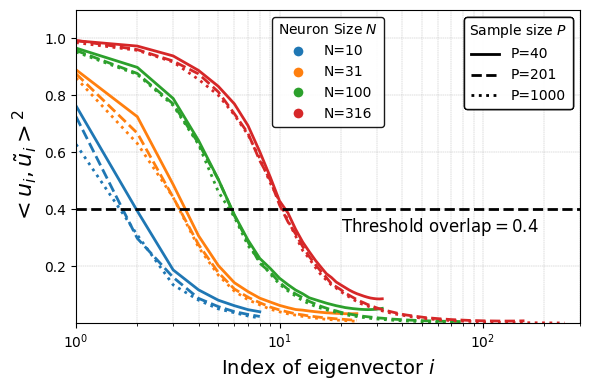

In [11]:
P_list = np.logspace(1.61, 3, 3, dtype=int)
N_list = np.logspace(1, 2.5, 4, dtype=int)
a_list = [0.2]
num_trials = 20

threshold_empirical_dict = {}

plt.style.use('default')
plt.figure(figsize=(6, 4))

for a in a_list:
    for P_index, P in enumerate(P_list):
        for N in N_list:
            print(f"P={P}, N={N}, a={a}")

            exponent = 1 + a
            pop_matrix = power_law_diag_matrix(P, exponent, device=device)
            mean, whole, e_value2 = overlap_pop_sample(pop_matrix, N, num_trials=num_trials)
            e_value1 = torch.diag(pop_matrix)

            e_value1 = e_value1.cpu().numpy()
            e_value2 = e_value2.cpu().numpy()

            q = P / N
            eta = 1 / np.sqrt(P)**2

            (overlap_theory, real_part_theory, imag_part_theory, numerator_theory,
             _, _, _, _) = compute_self_overlap(e_value2, e_value1, q, eta=eta,
                                                max_iter=10000, tol=1e-6)

            overlap_diag_theory = np.diag(overlap_theory)

            color = plt.cm.tab10(np.where(N_list == N)[0][0])

            rank = int(0.8*min(P, N))
            rank2 = int(0.6*min(P, N))

            skip = 1
            if P_index == 0:
                plt.plot(np.arange(1, rank + 1), overlap_diag_theory[:rank], color=color, linewidth=2)

            elif P_index == 1:
                plt.plot(np.arange(1, rank + 1), overlap_diag_theory[:rank], linestyle='--', color=color, linewidth=2)

            elif P_index == 2:
                plt.plot(np.arange(1, rank + 1), overlap_diag_theory[:rank], linestyle=':', color=color, linewidth=2)

            plt.xscale('log')
            # plt.yscale('log')

            # get the first index where the diagonal entries are less than 0.4
            threshold_idx_empirical = np.argmax(overlap_diag_theory < 0.4)
            print(f"P={P}, N={N}, a={a}, threshold_idx_empirical={threshold_idx_empirical}")
            # save it in dictionary for key being P={P}, N={N}, a={a}
            threshold_empirical_dict[f"P={P}, N={N}, a={a}"] = {"threshold_idx": threshold_idx_empirical}

        plt.xlabel(r"Index of eigenvector $i$", fontsize=14)
        plt.ylabel(r"$<u_i, \tilde{u}_i>^2$", fontsize=16)
        plt.grid(True, which='both', linestyle='--', linewidth=0.3)
        plt.ylim(1 / P, 1.1)
        plt.xlim(1, 300)
        linestyle_legend = [Line2D([0], [0], color='black', linestyle='solid', label=f"P={P_list[0]}", lw=2),
                            Line2D([0], [0], color='black', linestyle='--', label=f"P={P_list[1]}", lw=2),
                            Line2D([0], [0], color='black', linestyle='dotted', label=f"P={P_list[2]}", lw=2)]

        # Color legend for different N values(color in circle dot)
        color_legend = []
        for N in N_list:
            color = plt.cm.tab10(np.where(N_list == N)[0][0])
            color_legend.append(Line2D([0], [0], marker='o', color='w',
                                label=f"N={N}", markerfacecolor=color, markersize=8))

        # Plot the two separate legends
        first_legend = plt.legend(handles=linestyle_legend, loc='upper right', fontsize=10,
                                  frameon=True, framealpha=0.9, edgecolor='black',
                                  fancybox=True, title=r"Sample size $P$")
        plt.gca().add_artist(first_legend)  # Add the first legend to the plot

        # Second legend for the colors
        plt.legend(handles=color_legend, loc='upper center', fontsize=10, frameon=True,
                   framealpha=0.9, edgecolor='black', fancybox=True, title=r'Neuron Size $N$')

        # Tight layout to prevent overlap
        plt.tight_layout()
        # Show the plot

# make horizontal line at y=0.4
plt.axhline(y=0.4, color='black', linestyle='--', linewidth=2)
# write text y=0.4
plt.text(20, 0.32, r'$\text{Threshold overlap}=0.4$', fontsize=12)
# plt.savefig('./figures/overlap_varying_N_varying_P.pdf')